In [1]:
pip install pytorch-crf

In [2]:
import xml.etree.ElementTree as ET
import pandas as pd
from collections import defaultdict
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from torchcrf import CRF

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Устройство: {device}")

Устройство: cuda


In [4]:
def parse_xml_to_dataframe(xml_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    data = []

    # Проходим по всем предложениям
    for sentence in root.findall('sentence'):
        sentence_words = []

        # Собираем все слова в предложении
        for elem in sentence:
            if elem.tag == 'word':
                word_data = extract_word_features(elem, sentence)
                if word_data['allophones']:  # Добавляем только слова с аллофонами
                    sentence_words.append(word_data)

        # Обрабатываем аллофоны
        for i, word_data in enumerate(sentence_words):
            word_features = extract_contextual_word_features(word_data, sentence_words, i)
            allophone_features = extract_allophone_features(word_data, word_features)
            if allophone_features:
                data.extend(allophone_features)

    return pd.DataFrame(data)
#Признаки слов
def extract_word_features(word_elem, sentence):
    original_word = word_elem.get('original', '')
    clean_word = original_word.replace('.', '').replace(',', '').replace('?', '').replace('!', '').replace('-', '').replace('"', '')

    features = {
        'original_word': original_word,
        'nucleus': word_elem.get('nucleus', ''),
        'word_length': len(clean_word),
        'allophones': []
    }

    prev_ph = None
    for allophone in word_elem.findall('allophone'):
        current_ph = allophone.get('ph', '')
        if current_ph != prev_ph:
            features['allophones'].append(current_ph)
        prev_ph = current_ph

    dictitems = word_elem.findall('dictitem')
    if dictitems:
        dictitem = dictitems[0]
        features.update({
            'subpart_of_speech': dictitem.get('subpart_of_speech', ''),
            'form': dictitem.get('form', ''),
            'genesys': dictitem.get('genesys', ''),
            'semantics1': dictitem.get('semantics1', ''),
            'semantics2': dictitem.get('semantics2', ''),
            'stress_dict': dictitem.get('stress_dict', ''),
            'stress_additional_dict': dictitem.get('stress_additional_dict', '')
        })

    content_elems = sentence.findall('content')
    if content_elems:

        content = None
        for elem in sentence:
            if elem == word_elem:
                break
            if elem.tag == 'content':
                content = elem

        if content is not None:
            features.update({
                'PunktBeg': content.get('PunktBeg', ''),
                'PunktEnd': content.get('PunktEnd', ''),
                'EmphBeg': content.get('EmphBeg', ''),
                'EmphEnd': content.get('EmphEnd', ''),
                'LinkType': content.get('LinkType', '')
            })

    pause_elems = sentence.findall('pause')
    if pause_elems:
        for elem in sentence:
            if elem.tag == 'pause':
                features['pause_type'] = elem.get('type', '')
                features['pause_time'] = elem.get('time', '')
                break

    intonation_elems = sentence.findall('intonation')
    if intonation_elems:
        for elem in sentence:
            if elem.tag == 'intonation':
                features['intonation_type'] = elem.get('type', '')
                break

    return features

def extract_contextual_word_features(current_word, sentence_words, current_index):
    #Контекстные признаки
    features = {}

    prev_word = sentence_words[current_index - 1] if current_index > 0 else None
    next_word = sentence_words[current_index + 1] if current_index < len(sentence_words) - 1 else None

    features['prev_pos'] = prev_word.get('subpart_of_speech', '') if prev_word else ''
    features['next_pos'] = next_word.get('subpart_of_speech', '') if next_word else ''
    features['current_pos'] = current_word.get('subpart_of_speech', '')

    features['prev_semantics2'] = prev_word.get('semantics2', '') if prev_word else ''
    features['next_semantics2'] = next_word.get('semantics2', '') if next_word else ''

    features['position_in_sentence'] = current_index
    features['sentence_length'] = len(sentence_words)
    features['position_from_end'] = len(sentence_words) - current_index - 1

    significant_words = sum(1 for w in sentence_words if w.get('subpart_of_speech', '') not in ['9', '10'])
    features['significant_words_before'] = sum(1 for w in sentence_words[:current_index] if w.get('subpart_of_speech', '') not in ['9', '10'])
    features['significant_words_after'] = sum(1 for w in sentence_words[current_index+1:] if w.get('subpart_of_speech', '') not in ['9', '10'])

    return features

#Признаки аллофонов
def extract_allophone_features(word_data, word_features):
    allophone_data = []
    allophones = word_data['allophones']

    if not allophones:
        return []

    for i, allophone in enumerate(allophones):
        features = {
            'target_allophone': allophone,
            'allophone_position': i,
            'allophone_position_from_end': len(allophones) - i - 1,

            'prev_allophone': allophones[i-1] if i > 0 else '',
            'next_allophone': allophones[i+1] if i < len(allophones) - 1 else '',

            'original_word': word_data['original_word'],
            'word_length': word_data['word_length'],
            'nucleus': word_data.get('nucleus', ''),

            'subpart_of_speech': word_data.get('subpart_of_speech', ''),
            'form': word_data.get('form', ''),
            'genesys': word_data.get('genesys', ''),
            'semantics1': word_data.get('semantics1', ''),
            'semantics2': word_data.get('semantics2', ''),

            'stress_dict': word_data.get('stress_dict', ''),
            'stress_additional_dict': word_data.get('stress_additional_dict', ''),

            'prev_pos': word_features.get('prev_pos', ''),
            'current_pos': word_features.get('current_pos', ''),
            'next_pos': word_features.get('next_pos', ''),
            'prev_semantics2': word_features.get('prev_semantics2', ''),
            'position_in_sentence': word_features.get('position_in_sentence', ''),
            'position_from_end': word_features.get('position_from_end', ''),
            'significant_words_before': word_features.get('significant_words_before', ''),
            'significant_words_after': word_features.get('significant_words_after', ''),

            'PunktBeg': word_data.get('PunktBeg', ''),
            'PunktEnd': word_data.get('PunktEnd', ''),
            'LinkType': word_data.get('LinkType', ''),
            'pause_type': word_data.get('pause_type', ''),
            'pause_time': word_data.get('pause_time', ''),
            'intonation_type': word_data.get('intonation_type', '')
        }

        features.update(extract_phonetic_features(allophones, i))

        allophone_data.append(features)

    return allophone_data

#Фонетические признаки
def extract_phonetic_features(allophones, current_index):
    features = {}

    vowels = ['a', 'e', 'i', 'o', 'u', 'y', 'а', 'о', 'у', 'ы', 'э', 'я', 'ё', 'ю', 'и', 'е']
    current_ph = allophones[current_index].lower()

    current_ph_clean = ''.join([c for c in current_ph if not c.isdigit()])

    features['is_vowel'] = any(current_ph_clean.startswith(v) for v in vowels)
    features['is_consonant'] = not features['is_vowel'] and current_ph_clean != ''

    features['is_stressed'] = features['is_vowel'] and any(char.isdigit() for char in current_ph)

    def is_vowel_phoneme(ph):
        if not ph:
            return False
        ph_clean = ''.join([c for c in ph if not c.isdigit()])
        return any(ph_clean.startswith(v) for v in vowels)

    def is_stressed_phoneme(ph):
        return is_vowel_phoneme(ph) and any(char.isdigit() for char in ph)

    prev_ph = allophones[current_index-1] if current_index > 0 else ''
    next_ph = allophones[current_index+1] if current_index < len(allophones) - 1 else ''

    features['prev_stressed'] = is_stressed_phoneme(prev_ph)
    features['next_stressed'] = is_stressed_phoneme(next_ph)

    vowel_count = sum(1 for ph in allophones if is_vowel_phoneme(ph))
    consonant_count = sum(1 for ph in allophones if not is_vowel_phoneme(ph) and ph != '')

    features['vowel_count_in_word'] = vowel_count
    features['consonant_count_in_word'] = consonant_count

    vowel_positions = [j for j, ph in enumerate(allophones) if is_vowel_phoneme(ph)]

    if vowel_positions:
        prev_vowels = [pos for pos in vowel_positions if pos < current_index]
        if prev_vowels:
            features['distance_to_prev_vowel'] = current_index - max(prev_vowels)
        else:
            features['distance_to_prev_vowel'] = 0

        features['is_adjacent_to_vowel'] = any(abs(current_index - j) == 1 for j in vowel_positions)
    else:
        features['distance_to_prev_vowel'] = 0
        features['is_adjacent_to_vowel'] = False

    return features

df = parse_xml_to_dataframe('lab2.xml')



In [5]:
df.head(5)

,target_allophone,allophone_position,allophone_position_from_end,prev_allophone,next_allophone,original_word,word_length,nucleus,subpart_of_speech,form,...,intonation_type,is_vowel,is_consonant,is_stressed,prev_stressed,next_stressed,vowel_count_in_word,consonant_count_in_word,distance_to_prev_vowel,is_adjacent_to_vowel
0,i1,0,4,,d',Идиот,5,2,1,1,...,11,True,False,True,False,False,3,2,0,False
1,d',1,3,i1,i1,Идиот,5,2,1,1,...,11,False,True,False,True,True,3,2,1,True
2,i1,2,2,d',o0,Идиот,5,2,1,1,...,11,True,False,True,False,True,3,2,2,True
3,o0,3,1,i1,t,Идиот,5,2,1,1,...,11,True,False,True,True,False,3,2,1,True
4,t,4,0,o0,,Идиот,5,2,1,1,...,11,False,True,False,True,False,3,2,1,True


In [6]:
class PhoneticCRFDataset(Dataset):
    def __init__(self, words, char_sequences, phone_sequences, features):
        self.words = words
        self.char_sequences = torch.tensor(char_sequences, dtype=torch.long)
        self.phone_sequences = torch.tensor(phone_sequences, dtype=torch.long)
        self.features = torch.tensor(features, dtype=torch.float32)

    def __len__(self):
        return len(self.char_sequences)

    def __getitem__(self, idx):
        return (
            self.char_sequences[idx],
            self.phone_sequences[idx],
            self.features[idx],
            self.words[idx]
        )

def prepare_crf_data(df, max_word_len=20):

    word_data = df.groupby('original_word').agg({
        'target_allophone': list,
        'subpart_of_speech': 'first',
        'genesys': 'first',
        'semantics2': 'first',
        'is_stressed': list,
        'is_vowel': list,
        'is_consonant': list,
        'allophone_position': list,
        'stress_dict': 'first',
        'stress_additional_dict': 'first'
    }).reset_index()

    words, char_seqs, phone_seqs, feature_seqs = [], [], [], []

    for _, row in word_data.iterrows():
        word = row['original_word'].lower()
        word_clean = ''.join([c for c in word if c.isalpha()])
        phones = row['target_allophone']

        if (2 <= len(word_clean) <= max_word_len and
            len(word_clean) == len(phones)):

            try:
                # Базовые признаки
                subpart_pos = float(row['subpart_of_speech'] or 0) if str(row['subpart_of_speech']).strip() not in ['', 'nan'] else 0.0
                genesys_val = float(row['genesys'] or 0) if str(row['genesys']).strip() not in ['', 'nan'] else 0.0
                semantics_val = float(row['semantics2'] or 0) if str(row['semantics2']).strip() not in ['', 'nan'] else 0.0
                stress_dict = float(row['stress_dict'] or 0) if str(row['stress_dict']).strip() not in ['', 'nan'] else 0.0
                stress_add = float(row['stress_additional_dict'] or 0) if str(row['stress_additional_dict']).strip() not in ['', 'nan'] else 0.0

                # Статистические признаки
                is_stressed_clean = [x for x in row['is_stressed'] if pd.notna(x)]
                is_vowel_clean = [x for x in row['is_vowel'] if pd.notna(x)]

                stressed_ratio = sum(is_stressed_clean) / len(is_stressed_clean) if is_stressed_clean else 0.0
                vowel_ratio = sum(is_vowel_clean) / len(is_vowel_clean) if is_vowel_clean else 0.0
                consonant_ratio = 1.0 - vowel_ratio

                # Позиционные паттерны
                positions = [x for x in row['allophone_position'] if pd.notna(x)]
                pos_variance = np.var(positions) if len(positions) > 1 else 0.0

                # Сложность слова
                unique_phones = len(set(phones)) / len(phones) if phones else 0.0

                words.append(word_clean)
                char_seqs.append(list(word_clean))
                phone_seqs.append(phones)

                features = [
                    subpart_pos, genesys_val, semantics_val, stress_dict, stress_add,
                    len(word_clean) / max_word_len,  # Нормализованная длина
                    stressed_ratio, vowel_ratio, consonant_ratio,
                    pos_variance, unique_phones,
                    # One-hot для частых частей речи
                    1.0 if subpart_pos == 1 else 0.0,  # существительное
                    1.0 if subpart_pos == 6 else 0.0,  # глагол
                    1.0 if subpart_pos == 3 else 0.0,  # прилагательное
                ]
                feature_seqs.append(features)

            except Exception as e:
                continue

    print(f"Подготовлено {len(words)} слов с расширенными признаками")
    return words, char_seqs, phone_seqs, feature_seqs

In [7]:
class CNN_CRF_Phonetic(nn.Module):
    def __init__(self, char_vocab_size, phone_vocab_size, feature_dim,
                 char_embed_dim=128, hidden_dim=256, num_filters=128):
        super().__init__()

        self.char_embedding = nn.Embedding(char_vocab_size, char_embed_dim)

        # Многослойный CNN с разными размерами ядер
        self.conv3 = nn.Conv1d(char_embed_dim, num_filters, kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(char_embed_dim, num_filters, kernel_size=5, padding=2)
        self.conv7 = nn.Conv1d(char_embed_dim, num_filters, kernel_size=7, padding=3)

        self.conv_activation = nn.ReLU()
        self.dropout = nn.Dropout(0.4)

        # LSTM
        self.lstm = nn.LSTM(num_filters * 3 + feature_dim, hidden_dim // 2,
                           batch_first=True, bidirectional=True, num_layers=2, dropout=0.3)

        # Дополнительный линейный слой
        self.fc1 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc2 = nn.Linear(hidden_dim // 2, phone_vocab_size)

        self.crf = CRF(phone_vocab_size, batch_first=True)

    def forward(self, chars, features, phones=None):
        batch_size, seq_len = chars.shape

        char_embedded = self.char_embedding(chars)

        conv_input = char_embedded.transpose(1, 2)

        conv3_out = self.conv_activation(self.conv3(conv_input))
        conv5_out = self.conv_activation(self.conv5(conv_input))
        conv7_out = self.conv_activation(self.conv7(conv_input))

        conv_out = torch.cat([conv3_out, conv5_out, conv7_out], dim=1)
        conv_out = self.dropout(conv_out.transpose(1, 2))

        features_expanded = features.unsqueeze(1).repeat(1, seq_len, 1)
        combined = torch.cat([conv_out, features_expanded], dim=2)

        lstm_out, _ = self.lstm(combined)

        hidden = self.fc1(lstm_out)
        hidden = torch.relu(hidden)
        hidden = self.dropout(hidden)

        emissions = self.fc2(hidden)

        if phones is not None:
            mask = chars != 0
            loss = -self.crf(emissions, phones, mask=mask, reduction='mean')
            return loss
        else:
            mask = chars != 0
            return self.crf.decode(emissions, mask=mask)

In [8]:

# Подготавливаем данные с улучшенными признаками
words, char_seqs, phone_seqs, feature_seqs = prepare_crf_data(df)

# Создаем энкодеры для символов и фонем
all_chars = set()
all_phones = set()

for chars, phones in zip(char_seqs, phone_seqs):
    all_chars.update(chars)
    all_phones.update(phones)

# Добавляем специальные токены
all_chars.update(['<PAD>'])
all_phones.update(['<PAD>'])

char_encoder = LabelEncoder()
phone_encoder = LabelEncoder()

char_encoder.fit(list(all_chars))
phone_encoder.fit(list(all_phones))

print(f"Размер словаря символов: {len(char_encoder.classes_)}")
print(f"Размер словаря фонем: {len(phone_encoder.classes_)}")

# Кодируем последовательности
encoded_char_seqs = []
encoded_phone_seqs = []

# Находим максимальную длину последовательности
max_len = max(len(seq) for seq in char_seqs) if char_seqs else 0
print(f"Максимальная длина слова: {max_len}")

pad_char = char_encoder.transform(['<PAD>'])[0]
pad_phone = phone_encoder.transform(['<PAD>'])[0]

for chars, phones in zip(char_seqs, phone_seqs):
    # Кодируем символы
    try:
        encoded_chars = char_encoder.transform(chars).tolist()
    except ValueError as e:
        print(f"Ошибка кодирования символов {chars}: {e}")
        continue

    # Кодируем фонемы
    try:
        encoded_phones = phone_encoder.transform(phones).tolist()
    except ValueError as e:
        print(f"Ошибка кодирования фонем {phones}: {e}")
        continue

    # Паддинг
    if len(encoded_chars) < max_len:
        encoded_chars = encoded_chars + [pad_char] * (max_len - len(encoded_chars))
        encoded_phones = encoded_phones + [pad_phone] * (max_len - len(encoded_phones))

    encoded_char_seqs.append(encoded_chars)
    encoded_phone_seqs.append(encoded_phones)

# Преобразуем в numpy arrays
X_chars = np.array(encoded_char_seqs)
y_phones = np.array(encoded_phone_seqs)
X_features = np.array(feature_seqs)

print(f"Форма данных: X_chars {X_chars.shape}, y_phones {y_phones.shape}, X_features {X_features.shape}")
print(f"Размерность признаков: {X_features.shape[1]}")

Подготовлено 9612 слов с расширенными признаками
Размер словаря символов: 54
Размер словаря фонем: 57
Максимальная длина слова: 20
Форма данных: X_chars (9612, 20), y_phones (9612, 20), X_features (9612, 14)
Размерность признаков: 14


In [9]:
# Разделение на train/val/test
X_char_temp, X_char_test, y_phone_temp, y_phone_test, X_feat_temp, X_feat_test, words_temp, words_test = train_test_split(
    X_chars, y_phones, X_features, words, test_size=0.15, random_state=42
)

X_char_train, X_char_val, y_phone_train, y_phone_val, X_feat_train, X_feat_val, words_train, words_val = train_test_split(
    X_char_temp, y_phone_temp, X_feat_temp, words_temp, test_size=0.15, random_state=42
)

print(f"Train: {len(X_char_train)}, Val: {len(X_char_val)}, Test: {len(X_char_test)}")

# Создаем датасеты
train_dataset = PhoneticCRFDataset(words_train, X_char_train, y_phone_train, X_feat_train)
val_dataset = PhoneticCRFDataset(words_val, X_char_val, y_phone_val, X_feat_val)
test_dataset = PhoneticCRFDataset(words_test, X_char_test, y_phone_test, X_feat_test)

# DataLoader
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Параметры модели
char_vocab_size = len(char_encoder.classes_)
phone_vocab_size = len(phone_encoder.classes_)
feature_dim = X_features.shape[1]

print(f"Параметры модели: char_vocab={char_vocab_size}, phone_vocab={phone_vocab_size}, features={feature_dim}")

Train: 6944, Val: 1226, Test: 1442
Параметры модели: char_vocab=54, phone_vocab=57, features=14


In [11]:
def training_strategy(model, train_loader, val_loader, epochs=80):

    crf_params = [p for n, p in model.named_parameters() if 'crf' in n]
    other_params = [p for n, p in model.named_parameters() if 'crf' not in n]

    optimizer = optim.Adam([
        {'params': other_params, 'lr': 0.001},
        {'params': crf_params, 'lr': 0.01}  # CRF учим быстрее
    ], weight_decay=1e-5)

    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=1e-6
    )

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for batch_chars, batch_phones, batch_features, _ in train_loader:
            batch_chars = batch_chars.to(device)
            batch_phones = batch_phones.to(device)
            batch_features = batch_features.to(device)

            optimizer.zero_grad()

            loss = model(batch_chars, batch_features, batch_phones)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        avg_val_loss = validate_crf_model(model, val_loader)
        val_losses.append(avg_val_loss)

        scheduler.step()

        # Сохранение лучшей модели
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'epoch': epoch,
                'val_loss': avg_val_loss,
            }, 'best_crf_model_improved.pth')

        if epoch % 5 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f'Epoch {epoch:03d}: Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, LR: {current_lr:.6f}')

    return train_losses, val_losses

def validate_crf_model(model, val_loader):
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for batch_chars, batch_phones, batch_features, _ in val_loader:
            batch_chars = batch_chars.to(device)
            batch_phones = batch_phones.to(device)
            batch_features = batch_features.to(device)

            loss = model(batch_chars, batch_features, batch_phones)
            val_loss += loss.item()

    return val_loss / len(val_loader)

model = CNN_CRF_Phonetic(
    char_vocab_size=char_vocab_size,
    phone_vocab_size=phone_vocab_size,
    feature_dim=feature_dim,
    char_embed_dim=128,
    hidden_dim=256,
    num_filters=128
).to(device)


train_losses, val_losses = training_strategy(model, train_loader, val_loader, epochs=50)

Epoch 000: Train Loss: 12.1297, Val Loss: 3.1517, LR: 0.000976
Epoch 005: Train Loss: 0.5675, Val Loss: 0.6277, LR: 0.000346
Epoch 010: Train Loss: 0.5233, Val Loss: 0.6198, LR: 0.000994
Epoch 015: Train Loss: 0.3168, Val Loss: 0.6049, LR: 0.000794
Epoch 020: Train Loss: 0.1612, Val Loss: 0.5752, LR: 0.000422
Epoch 025: Train Loss: 0.1014, Val Loss: 0.5858, LR: 0.000096
Epoch 030: Train Loss: 0.2474, Val Loss: 0.6787, LR: 0.000998
Epoch 035: Train Loss: 0.2252, Val Loss: 0.6124, LR: 0.000946
Epoch 040: Train Loss: 0.1616, Val Loss: 0.8223, LR: 0.000825
Epoch 045: Train Loss: 0.1160, Val Loss: 0.6826, LR: 0.000655


Энкодеры и информация о модели сохранены!


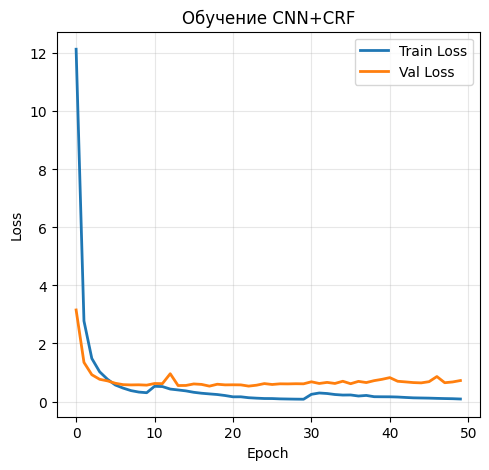

In [12]:
# Визуализация
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Val Loss', linewidth=2)
plt.title('Обучение CNN+CRF')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

joblib.dump(char_encoder, 'char_encoder_improved.pkl')
joblib.dump(phone_encoder, 'phone_encoder_improved.pkl')

model_info = {
    'char_vocab_size': char_vocab_size,
    'phone_vocab_size': phone_vocab_size,
    'feature_dim': feature_dim,
    'char_embed_dim': 128,
    'hidden_dim': 256,
    'num_filters': 128,
    'max_word_length': X_chars.shape[1],
    'feature_names': [
        'subpart_pos', 'genesys_val', 'semantics_val', 'stress_dict', 'stress_add',
        'norm_length', 'stressed_ratio', 'vowel_ratio', 'consonant_ratio',
        'pos_variance', 'unique_phones', 'is_noun', 'is_verb', 'is_adj'
    ]
}

with open('model_info_improved.json', 'w', encoding='utf-8') as f:
    json.dump(model_info, f, indent=2, ensure_ascii=False)

print("Энкодеры и информация о модели сохранены!")

# Загрузка лучшей модели
checkpoint = torch.load('best_crf_model_improved.pth', map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])

# Загружаем энкодеры
char_encoder = joblib.load('char_encoder_improved.pkl')
phone_encoder = joblib.load('phone_encoder_improved.pkl')

In [13]:
# Вычисляем WRR на тестовом наборе
def calculate_wrr(model, test_loader, phone_encoder):
    model.eval()
    correct_words = 0
    total_words = 0

    with torch.no_grad():
        for batch_chars, batch_phones, batch_features, batch_words in test_loader:
            batch_chars = batch_chars.to(device)
            batch_features = batch_features.to(device)
            batch_phones = batch_phones.to(device)

            predictions = model(batch_chars, batch_features)

            for i in range(len(batch_phones)):
                true_phones = batch_phones[i].cpu().numpy()
                pred_phones = predictions[i]

                pad_phone = phone_encoder.transform(['<PAD>'])[0]
                true_phones_clean = [p for p in true_phones if p != pad_phone]

                if len(true_phones_clean) == len(pred_phones):
                    if np.array_equal(true_phones_clean, pred_phones):
                        correct_words += 1
                total_words += 1

    wrr = correct_words / total_words if total_words > 0 else 0
    return wrr, correct_words, total_words

wrr, correct, total = calculate_wrr(model, test_loader, phone_encoder)
print(f"WRR: {wrr:.4f} ({correct}/{total} слов)")


WRR: 0.9383 (1353/1442 слов)
